<a href="https://colab.research.google.com/github/Krish-sharma-2003/ML-s-Google-Colab-Practice-Notes/blob/main/ADAMS_OPTIMIZER_vs_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import numpy as np
import matplotlib.pyplot as plt

In [42]:
def quadratic_loss(x, y):
  return x**2 + 10 * y **2


In [43]:
def quadratic_grad(x, y):
  dx = 2 * x
  dy = 20 * y
  return np.array([dx, dy])

In [44]:
def batch_gradient_descent(grad_func, eta, epochs, start_point):
  x,y = start_point
  path = [(x, y)]
  losses = [quadratic_loss(x, y)]

  for _ in range(epochs):
      grad = grad_func(x, y)
      x -= eta * grad[0]
      y -= eta * grad[1]
      path.append((x, y))
      losses.append(quadratic_loss(x, y))

  return np.array(path), losses

In [45]:
def adam_optimizer(grad_func, eta, beta1, beta2, epsilon, epochs, start_point):
    x, y = start_point
    m = np.array([0.0, 0.0]) # First Moments (MOMENTUM)
    v = np.array([0.0, 0.0]) # Second Moment (RMSProp)
    path = [(x, y)]
    losses = [quadratic_loss(x, y)]

    for t in range(1, epochs + 1):
      grad = grad_func(x, y) # Compute Gradients

      m = beta1 * m + (1 - beta1) * grad     # Update the Biased first moment estimate
      v = beta2 * v + (1-beta2) * grad **2   # Update the Biased second moment estimate

      # Bias Correction
      m_hat = m / (1 - beta1 ** t)
      v_hat = v / (1 - beta2 ** t)

      #Update parameters
      x -= eta * m_hat[0] / (np.sqrt(v_hat[0]) + epsilon)
      y -= eta * m_hat[1] / (np.sqrt(v_hat[1]) + epsilon)

      path.append((x, y))
      losses.append(quadratic_loss(x, y))


    return np.array(path), losses



In [46]:
def plot_paths(function, paths, labels, title):
    x, y = np.meshgrid(np.linspace(-2, 2, 400), np.linspace(-2, 2, 400))
    z = function(x, y)

    plt.figure(figsize=(8, 6))
    plt.contour(x, y, z, levels=50, cmap='jet')

    for path, label in zip(paths, labels):
        plt.plot(path[:, 0], path[:, 1], label=label)
        plt.scatter(path[0, 0], path[0, 1], color='green', label="start")
        plt.scatter(path[-1, 0], path[-1, 1], color='red', label="end")

    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()


In [47]:
def plot_losses(losses, labels, title):
  plt.figure(figsize=(8, 6))

  for loss, label in zip(losses, labels):

      plt.plot(loss, label=label)

  plt.title(title)
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

In [48]:
lr_qd = 0.2
lr_adam = 0.2
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8
epochs = 250
start_point = (1.5, 1.5) # Initial Point far from the minimum

In [49]:
path_gd, losses_gd = batch_gradient_descent(quadratic_grad, lr_qd, epochs, start_point)
path_adam, losses_adam = adam_optimizer(quadratic_grad, lr_adam, beta1, beta2, epsilon, epochs, start_point)


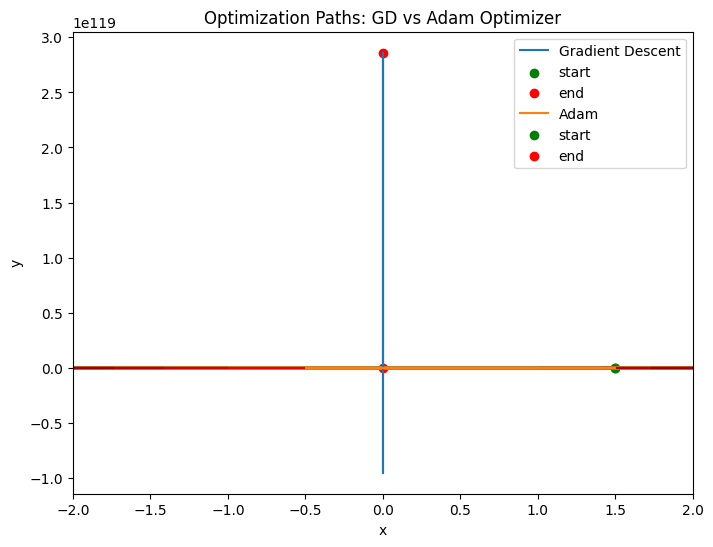

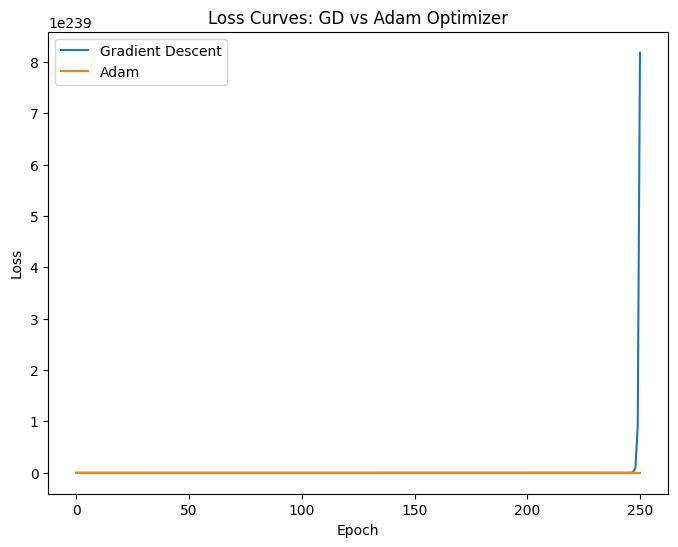

In [50]:
# Plot results
plot_paths(quadratic_loss, [path_gd, path_adam],
           ["Gradient Descent",  "Adam"],
           "Optimization Paths: GD vs Adam Optimizer")

plot_losses([losses_gd, losses_adam],
            ["Gradient Descent", "Adam"],
            "Loss Curves: GD vs Adam Optimizer")